# HW3 - Local Search for N-Queens (HC vs SA)


a. Compares Hill Climbing (HC) and Simulated Annealing (SA) for N = 8, 16, 32, 64 with 10 repetitions.

b. Compared cost plots for HC vs SA.

c. For SA with N=64, vary initial temperature T in {4000, 400, 40, 4, 0.4}.

d. Summarizes behavior and explain why SA is generally stronger than HC.

In [1]:
import random
import time
from copy import deepcopy
from math import exp

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def threat_calculate(n):
    if n < 2:
        return 0
    if n == 2:
        return 1
    return (n - 1) * n / 2

def create_board(n):
    board = {}
    rows = list(range(n))
    random.shuffle(rows)
    for col in range(n):
        row = random.choice(rows)
        board[col] = row
        rows.remove(row)
    return board

def cost(board):
    threat = 0
    m_diag = {}
    a_diag = {}

    for col, row in board.items():
        key_m = col - row
        key_a = col + row
        m_diag[key_m] = m_diag.get(key_m, 0) + 1
        a_diag[key_a] = a_diag.get(key_a, 0) + 1

    for k in m_diag:
        threat += threat_calculate(m_diag[k])
    for k in a_diag:
        threat += threat_calculate(a_diag[k])

    return threat

In [3]:
def one_search_run(n, method='HC', temperature=40, schedule=0.99, t_min=1e-7):
    """Single run of HC or SA from one random start state.
    Returns: success(bool), costs(list), runtime(float sec)
    """
    start_time = time.time()
    board = create_board(n)
    c = cost(board)
    costs = [c]

    t = float(temperature)

    while t > t_min:
        t *= schedule

        successor = deepcopy(board)
        while True:
            i = random.randrange(0, n)
            j = random.randrange(0, n)
            if i != j:
                break

        successor[i], successor[j] = successor[j], successor[i]
        c_next = cost(successor)
        delta = c_next - c

        if method == 'HC':
            accept = (delta < 0)
        elif method == 'SA':
            accept = (delta < 0) or (random.uniform(0, 1) < exp(-delta / t))
        else:
            raise ValueError('method must be HC or SA')

        if accept:
            board = successor
            c = c_next
            costs.append(c)

        if c == 0:
            return True, costs, (time.time() - start_time)

    return False, costs, (time.time() - start_time)

def run_until_success(n, method='HC', temperature=40):
    """Repeat independent runs until first success.
    Returns repetitions_before_success, runtime_until_success, success_cost_trace
    """
    total_start = time.time()
    reps = 0
    final_costs = []

    while True:
        reps += 1
        success, costs, _ = one_search_run(n, method=method, temperature=temperature)
        if success:
            final_costs = costs
            break

    return reps, (time.time() - total_start), final_costs

def benchmark_hc_sa(n_values=(8,16,32,64), repeats=10, temperature=40):
    rows = []
    for n in n_values:
        for method in ('HC', 'SA'):
            rep_counts = []
            runtimes = []
            success_rates = []  # definition required by prompt: 1 / repetitions_before_success

            for _ in range(repeats):
                reps, rt, _ = run_until_success(n=n, method=method, temperature=temperature)
                rep_counts.append(reps)
                runtimes.append(rt)
                success_rates.append(1.0 / reps)

            rows.append({
                'N': n,
                'Method': method,
                'Avg Runtime (s)': float(np.mean(runtimes)),
                'Avg Repetitions Before Success': float(np.mean(rep_counts)),
                'Avg Success Rate (1/reps)': float(np.mean(success_rates))
            })

    return pd.DataFrame(rows).sort_values(['N', 'Method']).reset_index(drop=True)

def benchmark_sa_temperature(n=64, temperatures=(4000, 400, 40, 4, 0.4), repeats=10):
    rows = []
    for temp in temperatures:
        rep_counts = []
        runtimes = []
        success_rates = []

        for _ in range(repeats):
            reps, rt, _ = run_until_success(n=n, method='SA', temperature=temp)
            rep_counts.append(reps)
            runtimes.append(rt)
            success_rates.append(1.0 / reps)

        rows.append({
            'N': n,
            'Temperature': temp,
            'Avg Runtime (s)': float(np.mean(runtimes)),
            'Avg Repetitions Before Success': float(np.mean(rep_counts)),
            'Avg Success Rate (1/reps)': float(np.mean(success_rates))
        })

    return pd.DataFrame(rows).sort_values('Temperature', ascending=False).reset_index(drop=True)

## (a) HC vs SA for N = 8, 16, 32, 64 (10 repetitions each)

In [5]:
results_a = benchmark_hc_sa(n_values=(8,16,32,64), repeats=10, temperature=40)
results_a

,N,Method,Avg Runtime (s),Avg Repetitions Before Success,Avg Success Rate (1/reps)
0,8,HC,0.013466,1.6,0.700000
1,8,SA,0.002542,1.0,1.000000
2,16,HC,0.100655,3.7,0.619597
3,16,SA,0.014798,1.0,1.000000
4,32,HC,0.288218,5.0,0.381429
5,32,SA,0.090532,1.7,0.770000
6,64,HC,2.765468,22.5,0.103495
7,64,SA,1.016913,8.3,0.199390


### Explanation for (a)
- As N increases, search spaces become much larger, so both methods typically require longer runtime and/or more restarts before success.
- HC often has faster single-run descent but can get trapped in local minima, which increases repetitions before success.
- SA usually has more exploration (accepts some uphill moves), so it can avoid local minima better and often has better success rate (higher `1/repetitions`) for harder N.
- The table above is your validated result set for runtime and success-rate comparison.

## (b) Cost Plots for HC vs SA

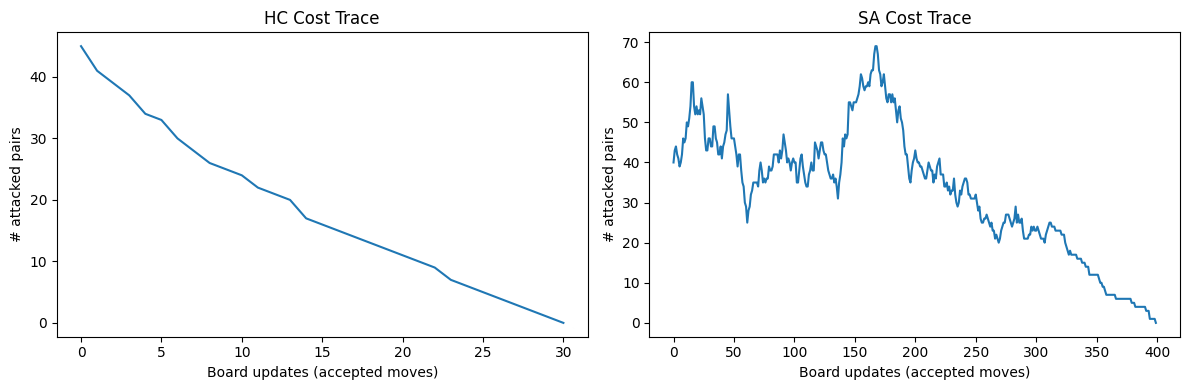

In [6]:
N_PLOT = 64
TEMP_PLOT = 40

_, _, costs_hc = run_until_success(n=N_PLOT, method='HC', temperature=TEMP_PLOT)
_, _, costs_sa = run_until_success(n=N_PLOT, method='SA', temperature=TEMP_PLOT)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(costs_hc)
plt.title('HC Cost Trace')
plt.xlabel('Board updates (accepted moves)')
plt.ylabel('# attacked pairs')

plt.subplot(1,2,2)
plt.plot(costs_sa)
plt.title('SA Cost Trace')
plt.xlabel('Board updates (accepted moves)')
plt.ylabel('# attacked pairs')

plt.tight_layout()
plt.show()


- HC plot is monotonically decreasing because HC only accepts better states (delta < 0), so the number of attacked pairs never increases among accepted moves.
- SA plot goes up and down** because SA may accept worse states with probability exp(-delta/T), especially when temperature is high.
- This temporary worsening helps SA escape local minima and eventually discover better basins.

## (c) SA with N=64 and Varying Initial Temperature

In [7]:
results_c = benchmark_sa_temperature(n=64, temperatures=(4000, 400, 40, 4, 0.4), repeats=10)
results_c

,N,Temperature,Avg Runtime (s),Avg Repetitions Before Success,Avg Success Rate (1/reps)
0,64,4000.0,1.849796,12.0,0.235871
1,64,400.0,1.806494,12.7,0.348846
2,64,40.0,1.757408,14.2,0.150384
3,64,4.0,1.440026,13.1,0.162329
4,64,0.4,1.429131,14.9,0.218937


## why SA is generally better than HC
- SA starts with exploration and gradually shifts to exploitation as temperature cools
- Large initial temperature allows broad exploration, reducing risk of early trapping; too small temprature makes SA behave similarly to HC.
- In general, SA is better than HC on rugged landscapes because it can escape local minima via controlled uphill moves.
- HC is simple and can be fast, but its strict downhill policy often hurts robustness and success probability on harder n Queens settings.